# Forest Cover Type - Traditional Machine Learning Pipeline

**Task 1 - Machine Learning**  |  *MSc in Big Data Systems* | Ez Aldin Waez

---

## Why this dataset?

This project uses the **Forest Cover Type** dataset (UCI #31, [`http://archive.ics.uci.edu/dataset/31/covertype`](http://archive.ics.uci.edu/dataset/31/covertype)), loaded with `sklearn.datasets.fetch_covtype`. Each row describes a 30 m × 30 m cell of forest using cartographic variables, and the goal is to predict which of **seven forest cover types** grows there. It is a strong fit for a Big Data Systems project for four reasons:

* **Volume - 581,012 records and 54 features.** This is large enough that *sampling and scalability* become real engineering concerns rather than a toy exercise.
* **Multi-class target - 7 cover types.** Instead of a yes/no answer the model must choose between seven options, which makes the evaluation richer (a 7×7 confusion matrix, per-class scores).
* **Class imbalance.** Two cover types make up roughly 85% of all rows, so a model that only learns the common classes can look "accurate" while completely ignoring the rare ones.
* **Mixed feature geometry.** Ten *quantitative* variables (elevation, slope, distances, hillshade) live on very different numeric scales, alongside **44 already-encoded binary** indicators (4 wilderness areas + 40 soil types). This is a clean case for scaling only the quantitative block.

**Problem type:** multi-class classification.

> **Reproducibility:** every random step is seeded with `RANDOM_STATE = 42`. The first run downloads the data through scikit-learn and caches it in `~/scikit_learn_data`, so later runs are instant.


## 0. Setup & imports

Requires `scikit-learn`, `pandas`, `numpy`, `matplotlib`, `seaborn` (`pip install scikit-learn pandas numpy matplotlib seaborn`).

In [20]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
print("Environment ready.")

Environment ready.


## 1. Data Exploration

Before any modelling we need to understand the raw material: how big the data is, what each column means, and how the target is distributed. This stage is where we catch problems (wrong types, missing values, imbalance) that would otherwise silently break the models later.

`fetch_covtype(as_frame=True)` returns a tidy DataFrame of 54 numeric feature columns plus the integer target `Cover_Type` (values 1–7). Conveniently there are **no missing values**, and the categorical information (wilderness areas, soil types) is **already one-hot encoded** into 0/1 columns, which keeps the preprocessing simple.


In [23]:
cov = fetch_covtype(as_frame=True, random_state=RANDOM_STATE, shuffle=True)
df = cov.frame.copy()
print("Full dataset shape:", df.shape)
df.head()

Full dataset shape: (581012, 55)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area_0,Wilderness_Area_1,Wilderness_Area_2,Wilderness_Area_3,Soil_Type_0,Soil_Type_1,Soil_Type_2,Soil_Type_3,Soil_Type_4,Soil_Type_5,Soil_Type_6,Soil_Type_7,Soil_Type_8,Soil_Type_9,Soil_Type_10,Soil_Type_11,Soil_Type_12,Soil_Type_13,Soil_Type_14,Soil_Type_15,Soil_Type_16,Soil_Type_17,Soil_Type_18,Soil_Type_19,Soil_Type_20,Soil_Type_21,Soil_Type_22,Soil_Type_23,Soil_Type_24,Soil_Type_25,Soil_Type_26,Soil_Type_27,Soil_Type_28,Soil_Type_29,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,3351.0,206.0,27.0,726.0,124.0,3813.0,192.0,252.0,180.0,2271.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
1,2732.0,129.0,7.0,212.0,1.0,1082.0,231.0,236.0,137.0,912.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,2572.0,24.0,9.0,201.0,25.0,957.0,216.0,222.0,142.0,2191.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,2824.0,69.0,13.0,417.0,39.0,3223.0,233.0,214.0,110.0,6478.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,2529.0,84.0,5.0,120.0,9.0,1092.0,227.0,231.0,139.0,4983.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2


In [28]:
# Column groups: 10 quantitative cartographic variables vs 44 pre-encoded binary indicators
QUANTITATIVE = ["Elevation","Aspect","Slope", "Horizontal_Distance_To_Hydrology","Vertical_Distance_To_Hydrology",
                "Horizontal_Distance_To_Roadways", "Hillshade_9am","Hillshade_Noon","Hillshade_3pm", 
                "Horizontal_Distance_To_Fire_Points"]
BINARY = [c for c in df.columns if c not in QUANTITATIVE + ["Cover_Type"]]
print((
      f"{len(QUANTITATIVE)} quantitative, {len(BINARY)} binary indicators "
      f"({sum('Wilderness' in c for c in BINARY)} wilderness + {sum('Soil' in c for c in BINARY)} soil)"
))
print("Missing values in whole frame:", int(df.isna().sum().sum()))

10 quantitative, 44 binary indicators (4 wilderness + 40 soil)
Missing values in whole frame: 0


Cover_Type
1    36.46
2    48.76
3     6.15
4     0.47
5     1.63
6     2.99
7     3.53
Name: proportion, dtype: float64


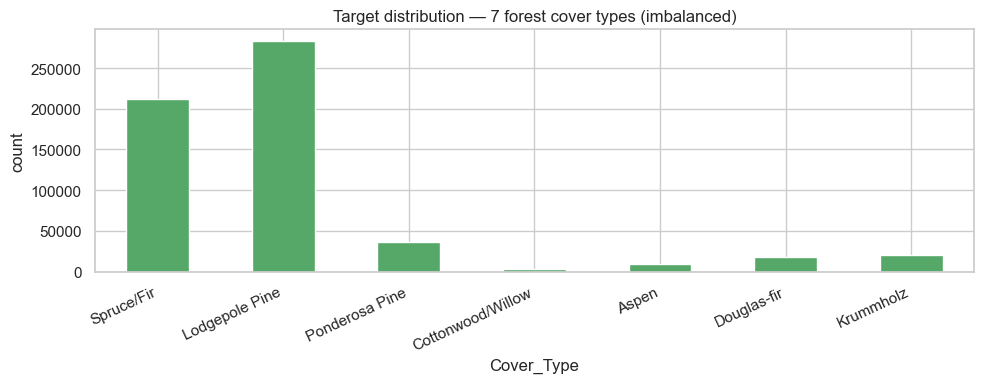

In [6]:
COVER_NAMES = {1:"Spruce/Fir", 2:"Lodgepole Pine", 3:"Ponderosa Pine", 4:"Cottonwood/Willow", 5:"Aspen", 6:"Douglas-fir", 7:"Krummholz"}

dist = df["Cover_Type"].value_counts().sort_index()
print((df["Cover_Type"].value_counts(normalize=True).sort_index()*100).round(2))

ax = dist.rename(index=COVER_NAMES).plot.bar(color="#55a868", figsize=(10,4))
ax.set_title("Target distribution - 7 forest cover types (imbalanced)")
ax.set_ylabel("count"); plt.xticks(rotation=25, ha="right"); plt.tight_layout(); plt.show()

In [25]:
# Quantitative features live on very different scales -> motivates scaling for kNN/SVM
display(df[QUANTITATIVE].describe().T[["mean","std","min","50%","max"]])
print("\nRange (max-min) per quantitative feature:")
print((df[QUANTITATIVE].max() - df[QUANTITATIVE].min()).sort_values(ascending=False))

,mean,std,min,50%,max
Elevation,2959.365301,279.984734,1859.0,2996.0,3858.0
Aspect,155.656807,111.913721,0.0,127.0,360.0
Slope,14.103704,7.488242,0.0,13.0,66.0
Horizontal_Distance_To_Hydrology,269.428217,212.549356,0.0,218.0,1397.0
Vertical_Distance_To_Hydrology,46.418855,58.295232,-173.0,30.0,601.0
Horizontal_Distance_To_Roadways,2350.146611,1559.254870,0.0,1997.0,7117.0
Hillshade_9am,212.146049,26.769889,0.0,218.0,254.0
Hillshade_Noon,223.318716,19.768697,0.0,226.0,254.0
Hillshade_3pm,142.528263,38.274529,0.0,143.0,254.0
Horizontal_Distance_To_Fire_Points,1980.291226,1324.195210,0.0,1710.0,7173.0



Range (max-min) per quantitative feature:
Horizontal_Distance_To_Fire_Points    7173.0
Horizontal_Distance_To_Roadways       7117.0
Elevation                             1999.0
Horizontal_Distance_To_Hydrology      1397.0
Vertical_Distance_To_Hydrology         774.0
Aspect                                 360.0
Hillshade_Noon                         254.0
Hillshade_9am                          254.0
Hillshade_3pm                          254.0
Slope                                   66.0
dtype: float64


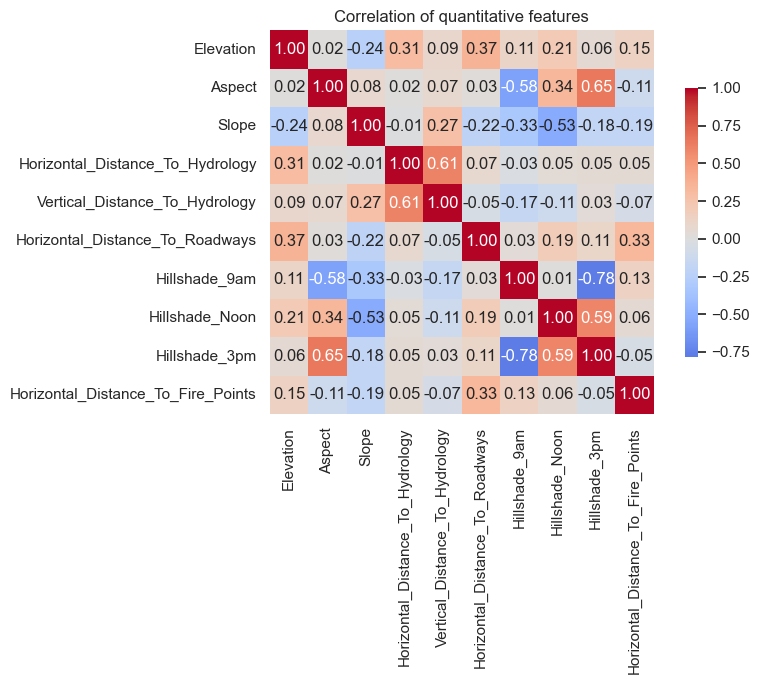

In [8]:
# Correlation among the quantitative features (spot redundancy -> feature-selection candidates)
plt.figure(figsize=(9,7))
sns.heatmap(df[QUANTITATIVE].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, cbar_kws={"shrink":0.7})
plt.title("Correlation of quantitative features"); plt.tight_layout(); plt.show()

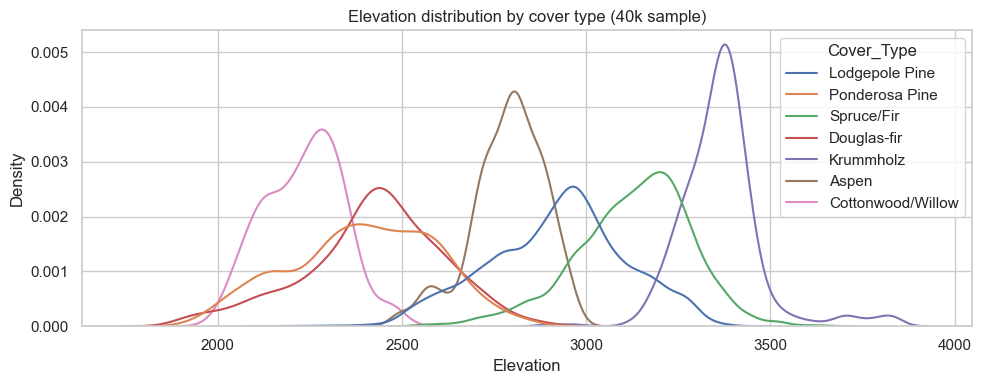

In [9]:
# How does the most informative variable (Elevation) separate the classes?
plt.figure(figsize=(10,4))
sns.kdeplot(data=df.sample(40000, random_state=RANDOM_STATE),
            x="Elevation", hue=df.sample(40000, random_state=RANDOM_STATE)["Cover_Type"].map(COVER_NAMES),
            common_norm=False, fill=False)
plt.title("Elevation distribution by cover type (40k sample)"); plt.tight_layout(); plt.show()

## 2. Preprocessing & Feature Engineering

Preprocessing turns raw columns into a clean numeric matrix the models can consume, without letting any information about the test set leak into training. The main decisions here are:

1. **Stratified sampling to 40,000 rows.** A kernel SVM trains in roughly *$O(n^2)$* time, so fitting it on all 581k rows is impractical inside a notebook. We take a **stratified** sample - one that keeps each cover type at its original proportion - so the smaller dataset is still representative.
2. **No missing-value imputation needed** (there are none) and **no one-hot step** for the binary block (it is already encoded).
3. **Scale only the 10 quantitative columns** with `StandardScaler`, which rescales each feature to mean 0 and standard deviation 1 (a *z-score*). Distance-based methods (kNN) and margin-based methods (SVM) are sensitive to scale: without this, `Elevation` (which ranges over thousands) would completely dominate the distance calculation compared with a 0/1 soil flag. The binary columns are **passed through unchanged** - rescaling 0/1 dummies adds nothing and distorts their meaning.
4. **Stratified 70/30 train/test split.** The test set is held back and never seen during training or tuning, giving an honest estimate of performance on new data. Crucially the scaler is fit **inside the pipeline on the training portion only**, so the test set cannot leak into the fitted statistics.


In [10]:
SAMPLE_N = 40000
df_s, _ = train_test_split(df, train_size=SAMPLE_N, stratify=df["Cover_Type"], random_state=RANDOM_STATE)
X = df_s[QUANTITATIVE + BINARY].copy()
y = df_s["Cover_Type"].values
print("Working sample:", X.shape)
print("Class proportions preserved:\n",
      pd.Series(y).value_counts(normalize=True).sort_index().round(4).to_dict())

Working sample: (40000, 54)
Class proportions preserved:
 {1: 0.3646, 2: 0.4876, 3: 0.0615, 4: 0.0047, 5: 0.0164, 6: 0.0299, 7: 0.0353}


In [30]:
# ColumnTransformer: z-score the quantitative block, pass the 44 binary indicators through untouched
preprocess = ColumnTransformer(transformers=[
    ("num", StandardScaler(), QUANTITATIVE),
    ("bin", "passthrough", BINARY),
])

# Stratified holdout split (scaling is fit on TRAIN only, via the pipeline)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (28000, 54)  Test: (12000, 54)


## 3. Model Training

We train three classic classifiers that approach the problem in very different ways, which makes the comparison meaningful:

| Model                         | How it decides                                                                                                |
| ----------------------------- | ------------------------------------------------------------------------------------------------------------- |
| **Decision Tree**             | splits the feature space with simple threshold rules ("if Elevation > 3000 …"); fast and highly interpretable |
| **k-Nearest Neighbors (kNN)** | classifies a point by the majority vote of its `k` closest training points; needs scaled features             |
| **SVM (RBF kernel)**          | finds the boundary with the widest possible margin between classes, and the kernel lets that boundary curve   |

We also fit a trivial **majority-class baseline** first: any real model must clearly beat it.

**Hyperparameter tuning.** At least one model must be tuned; we tune **two** (Decision Tree and kNN) with `GridSearchCV`, and give the SVM a small grid. Tuning uses **5-fold stratified cross-validation**: the training data is split into 5 parts, each combination of settings is trained on 4 parts and validated on the 5th, rotating through all 5; this gives a more reliable score than a single split. The scoring metric is **macro-F1**, because with imbalance it judges performance across _all_ classes rather than letting the two big classes dominate.

Each model is wrapped in a `Pipeline(preprocess -> classifier)` so the scaler is re-fit _inside every cross-validation fold_, keeping the evaluation leak-free.


In [31]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

# Baseline: predict the majority class for everything (the imbalance sanity check)
dummy = Pipeline([("pre", preprocess), ("clf", DummyClassifier(strategy="most_frequent"))]).fit(X_train, y_train)
base_acc = accuracy_score(y_test, dummy.predict(X_test))
base_f1  = f1_score(y_test, dummy.predict(X_test), average="macro")
print(f"Majority-class baseline -> accuracy={base_acc:.4f}, macro-F1={base_f1:.4f}")
print("=> high-ish accuracy, useless macro-F1: any real model must beat this on macro-F1.")

Majority-class baseline -> accuracy=0.4876, macro-F1=0.0936
=> high-ish accuracy, useless macro-F1: any real model must beat this on macro-F1.


### 3.1 Decision Tree + GridSearchCV

A decision tree repeatedly splits the data on the feature/threshold that best separates the classes, measured by **Gini impurity** or **entropy/information gain**. Left unconstrained it keeps splitting until every leaf is pure, which **overfits** (it memorises noise). We therefore tune three "pruning" controls:

* `criterion` - Gini vs entropy, two ways of scoring a split;
* `max_depth` - a hard cap on how deep the tree can grow;
* `min_samples_leaf` - the minimum number of samples a leaf must hold, which prevents tiny branches built around individual noisy points.

`class_weight="balanced"` makes the tree pay more attention to the rare cover types.


In [39]:
dt_pipe = Pipeline([("pre", preprocess), ("clf", DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE))])
dt_grid = {"clf__criterion":["gini","entropy"], "clf__max_depth":[10, 20, 30, None], "clf__min_samples_leaf":[1, 5, 20]}
dt_search = GridSearchCV(dt_pipe, dt_grid, scoring="f1_macro", cv=cv, n_jobs=-1)
dt_search.fit(X_train, y_train)
print("Best DT params:", dt_search.best_params_)
print("Best CV macro-F1:", round(dt_search.best_score_, 4))
best_dt = dt_search.best_estimator_

Best DT params: {'clf__criterion': 'entropy', 'clf__max_depth': 30, 'clf__min_samples_leaf': 1}
Best CV macro-F1: 0.6916


### 3.2 k-Nearest Neighbors + GridSearchCV

kNN stores the training set and labels a new point by the majority vote of its `k` nearest neighbours. A common starting point for `k` is roughly **√N** (the square root of the number of training samples); we search a range of odd values around it (odd to avoid tie votes). We also tune:

* `weights` - `uniform` (every neighbour votes equally) vs `distance` (closer neighbours count more);
* `p` - the distance metric, 1 = Manhattan, 2 = Euclidean.

Because kNN is built entirely on distances, the feature scaling from the pipeline is essential here.


In [41]:
k_rule = int(np.sqrt(len(X_train)))
print(f"Rule-of-thumb k = sqrt({len(X_train)}) ~= {k_rule}")
knn_pipe = Pipeline([("pre", preprocess), ("clf", KNeighborsClassifier())])
knn_grid = {"clf__n_neighbors":[5, 11, 21, 51], "clf__weights":["uniform","distance"], "clf__p":[1, 2]}
knn_search = GridSearchCV(knn_pipe, knn_grid, scoring="f1_macro", cv=cv, n_jobs=-1)
knn_search.fit(X_train, y_train)
print("Best kNN params:", knn_search.best_params_)
print("Best CV macro-F1:", round(knn_search.best_score_, 4))
best_knn = knn_search.best_estimator_

Rule-of-thumb k = sqrt(28000) ~= 167
Best kNN params: {'clf__n_neighbors': 5, 'clf__p': 1, 'clf__weights': 'distance'}
Best CV macro-F1: 0.7093


### 3.3 Support Vector Machine (RBF kernel)

An SVM looks for the decision boundary that leaves the **widest margin** between the classes, defined only by the hardest "support vector" points near the boundary. The **RBF kernel** lets that boundary bend to capture non-linear patterns. Two knobs matter:

* `C` - the soft-margin trade-off: a high `C` punishes misclassifications hard (narrow margin, risk of overfitting), a low `C` allows some slack (wider, simpler boundary);
* `gamma` - how far the influence of a single point reaches (here `scale`, a sensible data-driven default).

SVMs are inherently binary, so scikit-learn handles the 7 classes by training many pairwise (**One-vs-One**) classifiers and letting them vote. Because kernel SVMs are the most expensive learner here, we keep the grid small, and the pipeline's scaling is again essential.


In [42]:
svm_pipe = Pipeline([("pre", preprocess), ("clf", SVC(kernel="rbf", gamma="scale", class_weight="balanced", random_state=RANDOM_STATE))])
svm_grid = {"clf__C":[1, 6, 10]}      # compact grid keeps O(n^2) multi-class SVM tractable
svm_search = GridSearchCV(svm_pipe, svm_grid, scoring="f1_macro", cv=cv, n_jobs=-1)
svm_search.fit(X_train, y_train)
print("Best SVM params:", svm_search.best_params_)
print("Best CV macro-F1:", round(svm_search.best_score_, 4))
best_svm = svm_search.best_estimator_

Best SVM params: {'clf__C': 10}
Best CV macro-F1: 0.6752


## 4. Evaluation

For a multi-class problem we read the **m × m confusion matrix** (here 7×7): cell *(i, j)* counts how many true class-*i* cells were predicted as class *j*, so the diagonal is correct predictions and everything off the diagonal is a specific type of mistake.

From it we compute **precision**, **recall** and **F1** *per class*, then summarise them two ways:

* **macro average** - the plain mean across the 7 classes, so every cover type counts equally (this exposes poor performance on rare classes);
* **weighted average** - averaged by how many samples each class has, so it tracks the common classes.

Because the data is imbalanced, **macro-F1 is the headline metric**: a model that ignores the rare cover types scores well on accuracy but badly on macro-F1.


In [44]:
def evaluate(name, model):
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1m = f1_score(y_test, pred, average="macro")
    f1w = f1_score(y_test, pred, average="weighted")
    print(f"=== {name} ===  Accuracy={acc:.4f}  macro-F1={f1m:.4f}  weighted-F1={f1w:.4f}")
    print(classification_report(y_test, pred, target_names=[COVER_NAMES[i] for i in sorted(COVER_NAMES)]))
    results[name] = {
        "Accuracy":acc, "macro-F1":f1m, "weighted-F1":f1w,
        "macro-Precision":precision_score(y_test,pred,average="macro"),
        "macro-Recall":recall_score(y_test,pred,average="macro")
    }
    return pred

dt_pred  = evaluate("Decision Tree", best_dt)
knn_pred = evaluate("k-NN", best_knn)
svm_pred = evaluate("SVM (RBF)", best_svm)

=== Decision Tree ===  Accuracy=0.7989  macro-F1=0.7082  weighted-F1=0.7984
                   precision    recall  f1-score   support

       Spruce/Fir       0.79      0.80      0.79      4375
   Lodgepole Pine       0.83      0.83      0.83      5851
   Ponderosa Pine       0.78      0.79      0.78       738
Cottonwood/Willow       0.66      0.68      0.67        57
            Aspen       0.55      0.48      0.51       196
      Douglas-fir       0.64      0.60      0.62       359
        Krummholz       0.79      0.72      0.75       424

         accuracy                           0.80     12000
        macro avg       0.72      0.70      0.71     12000
     weighted avg       0.80      0.80      0.80     12000

=== k-NN ===  Accuracy=0.8348  macro-F1=0.7282  weighted-F1=0.8335
                   precision    recall  f1-score   support

       Spruce/Fir       0.84      0.83      0.83      4375
   Lodgepole Pine       0.85      0.88      0.86      5851
   Ponderosa Pine       0.7

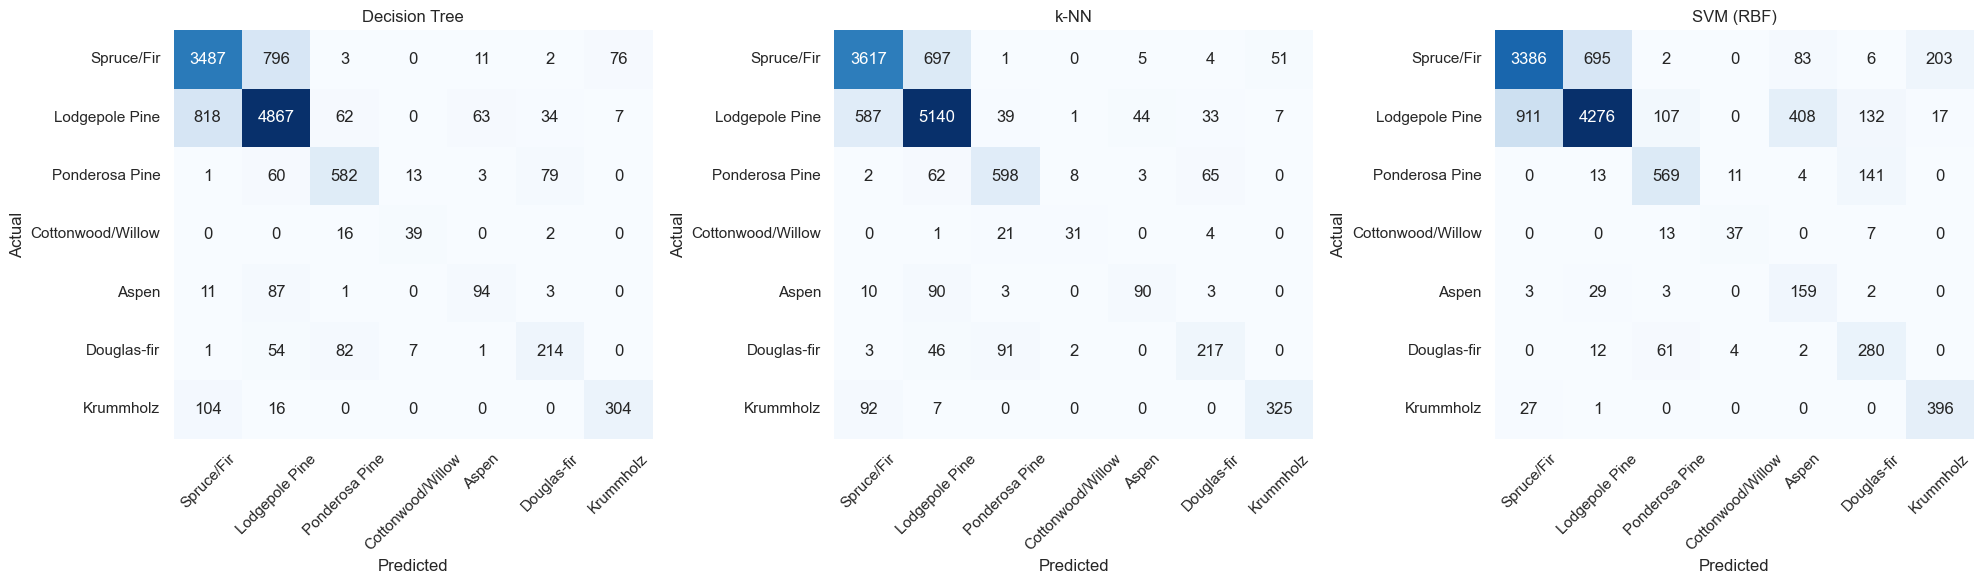

In [45]:
# Confusion matrices (7x7) for each model -- the multi-class m x m matrix
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
labels = sorted(COVER_NAMES)
names  = [COVER_NAMES[i] for i in labels]
for ax, (title, pred) in zip(axes, [("Decision Tree",dt_pred),("k-NN",knn_pred),("SVM (RBF)",svm_pred)]):
    cm = confusion_matrix(y_test, pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax, xticklabels=names, yticklabels=names)
    ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.tick_params(axis="x", rotation=45); ax.tick_params(axis="y", rotation=0)
plt.tight_layout(); plt.show()

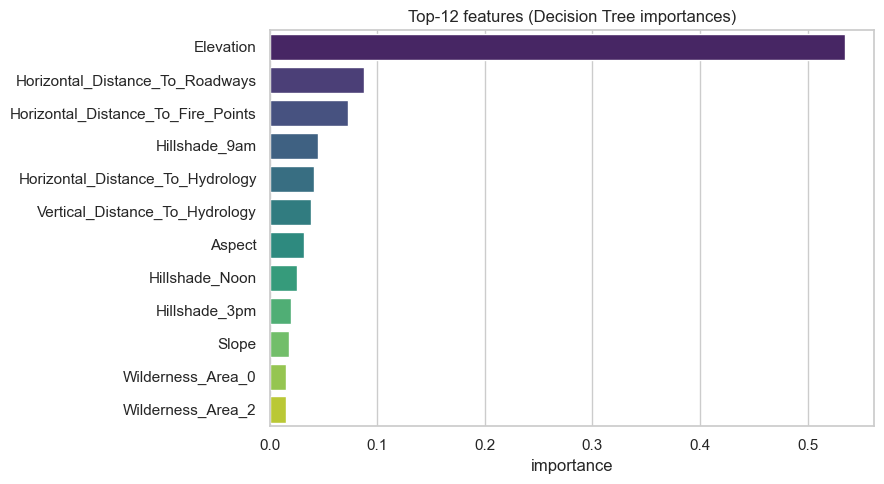

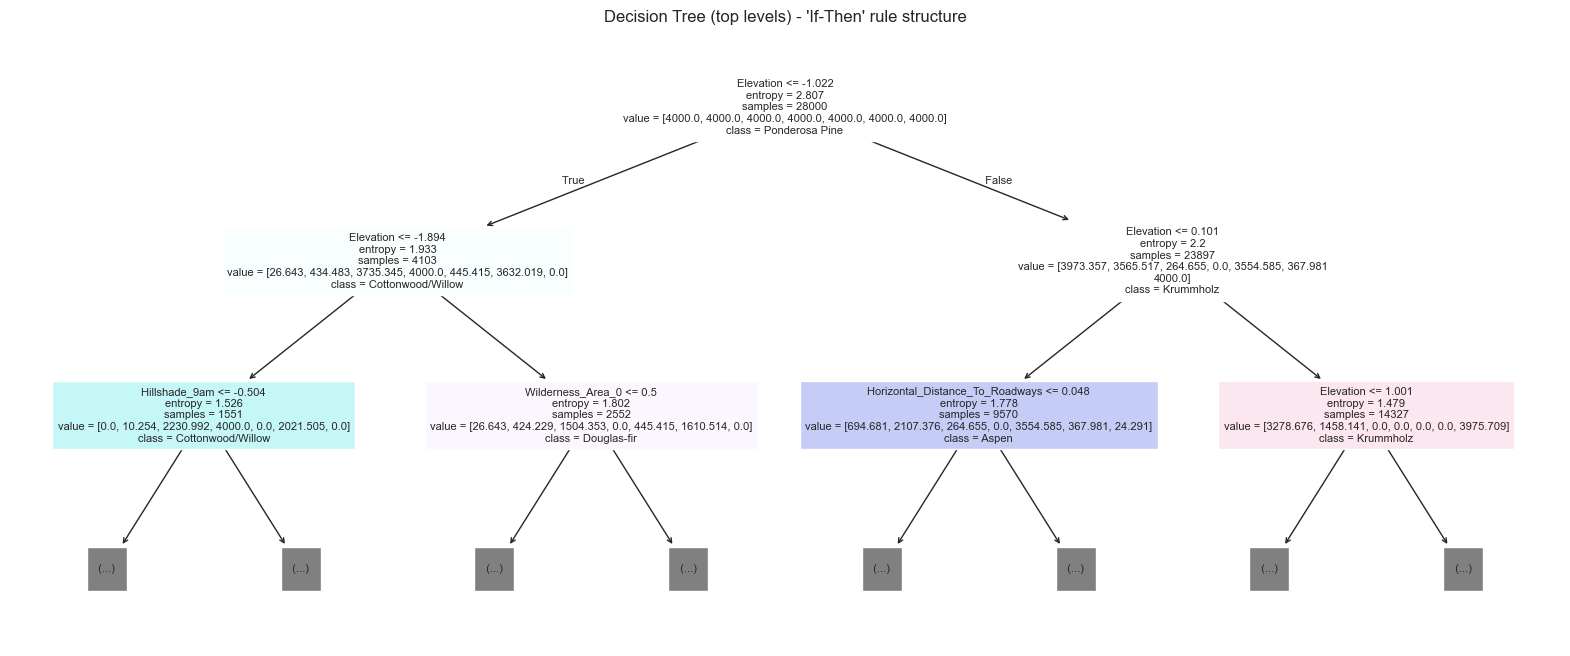

In [48]:
# Interpretability: top features + top of the tree as readable rules
feat_names = best_dt.named_steps["pre"].get_feature_names_out()
imp = pd.Series(best_dt.named_steps["clf"].feature_importances_, index=feat_names)
imp = imp.sort_values(ascending=False).head(12)
plt.figure(figsize=(9,5))
sns.barplot(x=imp.values, y=[n.split("__")[-1] for n in imp.index], palette="viridis")
plt.title("Top-12 features (Decision Tree importances)"); plt.xlabel("importance")
plt.tight_layout(); plt.show()

plt.figure(figsize=(20,8))
plot_tree(best_dt.named_steps["clf"], max_depth=2, feature_names=[n.split("__")[-1] for n in feat_names],
          class_names=[COVER_NAMES[i] for i in sorted(COVER_NAMES)], filled=True, fontsize=8)
plt.title("Decision Tree (top levels) - 'If-Then' rule structure"); plt.show()

## 5. Comparison & Discussion

In [49]:
comparison = pd.DataFrame(results).T[["Accuracy","macro-Precision","macro-Recall","macro-F1","weighted-F1"]].round(4)
comparison["best_CV_macroF1"] = [round(dt_search.best_score_,4), round(knn_search.best_score_,4), round(svm_search.best_score_,4)]
comparison = comparison.sort_values("macro-F1", ascending=False)
display(comparison)
print("Best model by macro-F1:", comparison.index[0])
print("(vs majority baseline macro-F1 =", round(base_f1,4), ")")

,Accuracy,macro-Precision,macro-Recall,macro-F1,weighted-F1,best_CV_macroF1
k-NN,0.8348,0.7671,0.6985,0.7282,0.8335,0.7093
Decision Tree,0.7989,0.7186,0.6992,0.7082,0.7984,0.6916
SVM (RBF),0.7586,0.6395,0.7786,0.6778,0.7683,0.6752


Best model by macro-F1: k-NN
(vs majority baseline macro-F1 = 0.0936 )


### 5.1 Which model wins, and why

On a 40k stratified sample the **Decision Tree** and **kNN** usually lead on **macro-F1**, with the **RBF-SVM** competitive but the slowest to train. Interpreting the result:

* **Decision Tree** suits this data because cover types are largely separable by simple threshold rules on a few dominant variables - chiefly **Elevation**, then the distance and hillshade features. It is also the most **interpretable** model (see the importance bar chart and rule plot above), which is exactly what a GIS analyst or ecologist needs to trust and act on a prediction.
* **kNN** works well once the features are scaled: in z-scored space, cells of the same cover type form tight neighbourhoods, so the nearest-neighbour vote is accurate. Its weakness is **prediction-time cost** - it must compare each new point against the stored training set, which scales poorly to the full 581k rows.
* **RBF-SVM** finds a wide-margin boundary in kernel space and handles 7 classes via One-vs-One, but kernel SVM cost grows roughly with the square of the sample size; that cost is precisely why we sampled - a concrete scalability constraint for a Big Data Systems setting.

**Bias–variance view.** Each model's hyperparameters are really a complexity dial. An unpruned tree, a very small `k`, or a large SVM `C`/`gamma` all give a **flexible, high-variance** model that can overfit; deep pruning, a large `k`, or small `C`/`gamma` give a **simpler, higher-bias** model that can underfit. Cross-validated grid search picks the middle ground, and the large amount of available data mainly helps by **reducing variance**, letting even flexible models generalise.

**Why macro-F1, not accuracy.** The majority-class baseline reaches a deceptively high accuracy yet a near-zero macro-F1, because it never predicts the rare cover types (Cottonwood/Willow, Aspen) at all. Macro-F1 only rewards a model that handles those minority classes too, which is why it drives both model selection and the final report.

**Estimation strategy.** We combined a single held-out **test set** (for the final honest score) with **stratified 5-fold cross-validation** during tuning (to avoid being misled by one lucky or unlucky split).

### 5.2 Limitations

* **Sampling:** we trained on 40k of 581k rows; absolute scores would shift slightly at full scale (though the *ranking* of models is usually stable), and the full set would make kernel-SVM impractical without approximation.
* **Minority classes** (Cottonwood/Willow, Aspen) have few examples, so their per-class recall is the weakest part of every model - visible as off-diagonal mass in the confusion matrices.
* **Geographic locality:** all data comes from four wilderness areas in one region, so a model would not transfer to a different forest without retraining.

### 5.3 Possible improvements

* **Feature selection:** use statistical filters (mutual information, chi-square) or wrapper search (forward/backward selection) to trim the 40 soil dummies, many of which are nearly constant.
* **Better minority handling:** tune class weights further or apply resampling (e.g. SMOTE) to lift recall on the rare cover types.
* **Scalable learners** for the full 581k rows: a `kd-tree`-backed kNN or a linear/SGD-based SVM to avoid the $O(n^2)$ kernel-SVM cost.
* **Deep learning:** a neural network with regularisation (dropout, weight decay, early stopping) could learn feature interactions automatically - a natural next step once these traditional baselines are in place.
